<a href="https://colab.research.google.com/github/abogdanov93/part_1_ml_cv/blob/main/week_08_semantic_segmentation/Homework/hw_6_semantic_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Загрузка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>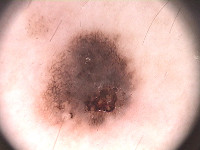</td><td>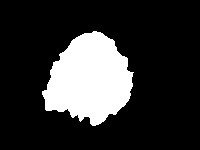</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [2]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=b8ba21b0-0990-4602-8853-9ccf357bebba
To: /content/PH2Dataset.rar
100% 162M/162M [00:00<00:00, 184MB/s]


In [3]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [4]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [5]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [6]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

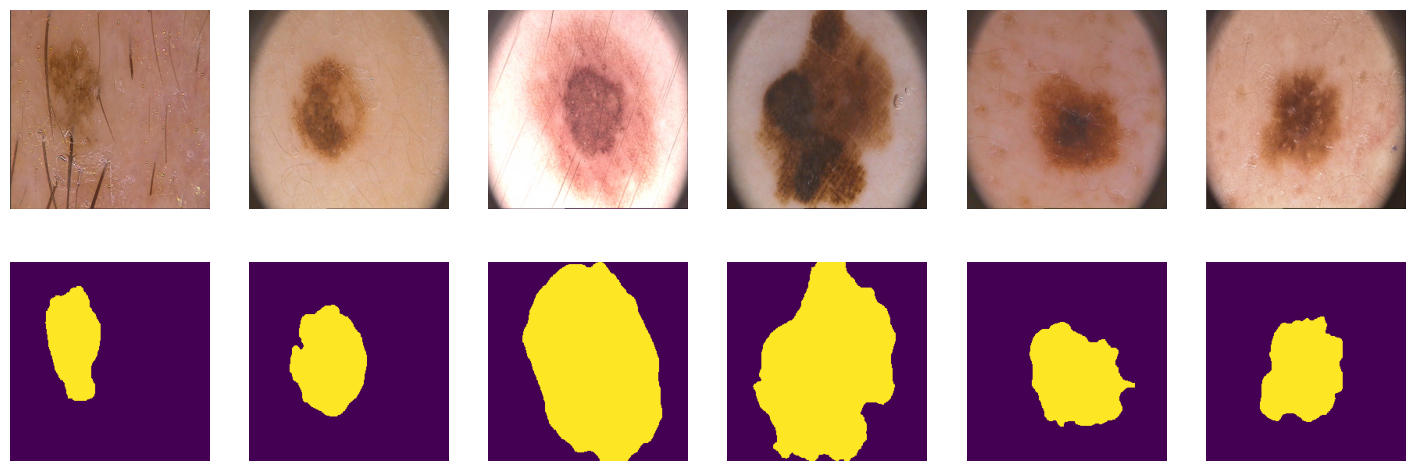

In [7]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [8]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [9]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [10]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=True)

In [11]:
for i in train_dataloader:
    print(i[1].shape)
    break

torch.Size([25, 1, 256, 256])


In [12]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Метрика

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [13]:
!pip install torchmetrics

In [14]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## BCE Loss [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.



**Ответ:** Здесь как-то странно написаны формулы, первая это сумма по компонентам, а вторая выглядит как будто это вектор, но это не может быть вектор, т.к. мы не можем из вектора вычесть произведение вектороа потом добавить логарифм от сложного выражения вектора. Вторая формула это просто один индекс из первой. Выведем это

Напишем один компонент в первой формуле

$$
L_i(y, \hat y)= -\left[y_i \ln \sigma(\hat y_i) + (1 - y_i) \ln(1 - \sigma(\hat y_i))\right]
= -\left[y_i \ln \left(\frac{1}{1 + e^{-\hat y_i}}\right) + (1 - y_i) \ln \left(1 - \frac{1}{1 + e^{-\hat y_i}}\right) \right]
$$


Первое выражение:

Вспомним как работают логарифмы:
$$ ln(a^b) = b\ln(a) $$

$$  \ln \left(\frac{1}{1 + e^{-\hat y_i}}\right) = -\ln(1 + e^{-\hat y_i}) $$




Второе выражение:
$$ 1 - \frac{1}{1 + e^{-\hat y_i}} = \frac {1 + e^{-\hat y_i} - 1} {1 + e^{-\hat y_i}} = \frac {e^{-\hat y_i}} {1 + e^{-\hat y_i}}$$

$$ ln \frac {a} {b} = ln(a) - ln(b) $$
$$ ln(e^x) = x $$

$$ ln \frac {e^{-\hat y_i}} {1 + e^{-\hat y_i}} = -\hat y_i - ln(1 + e^{-\hat y_i}) $$

Подставим все в исходное выражение

$$
L_i(y, \hat y)= y_i \ln(1 + e^{-\hat y_i}) - (1 - y_i) (-\hat y_i - ln(1+e^{-\hat y_i})) $$
$$ L_i(y, \hat y) = y_i \ln(1 + e^{-\hat y_i}) + \hat y_i + ln(1+e^{-\hat y_i}) - y_i \hat y_i - y_i \ ln(1 + e^{-\hat y_i}) $$

$$ L_i(y, \hat y) = \hat y_i - y_i \hat y_i + ln(1+e^{-\hat y_i}) $$

Получилось!

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [15]:
import torch.nn.functional as F
import torch.nn as nn

In [16]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [17]:
def bce_loss(y_pred, y_real):
  return torch.sum(y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred)))

def bce_true(y_pred, y_real):
  return -torch.sum(y_real * torch.log(torch.sigmoid(y_pred)) + (1 - y_real) * torch.log(1 - torch.sigmoid(y_pred)))

Проверим корректность работы на простом примере

In [18]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss = 4.84184455871582
BCE loss честно посчитанный = 4.84184455871582
BCE loss from torch bce_torch = 4.84184455871582
BCE loss from torch with logits bce_torch = 4.84184455871582


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [20]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss = 14.45858383178711
BCE loss честно посчитанный = 14.458582878112793
BCE loss from torch bce_torch = 14.458582878112793
BCE loss from torch with logits bce_torch = 14.458581924438477


In [21]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [22]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 5.88MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 5.27MB/s]
Download completed


In [23]:
path_to_dummy_samples = './for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

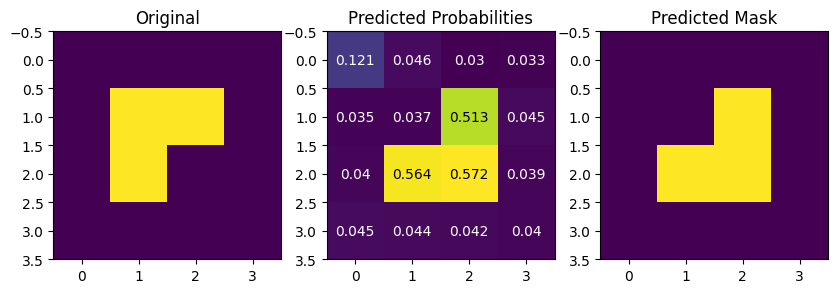

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [25]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

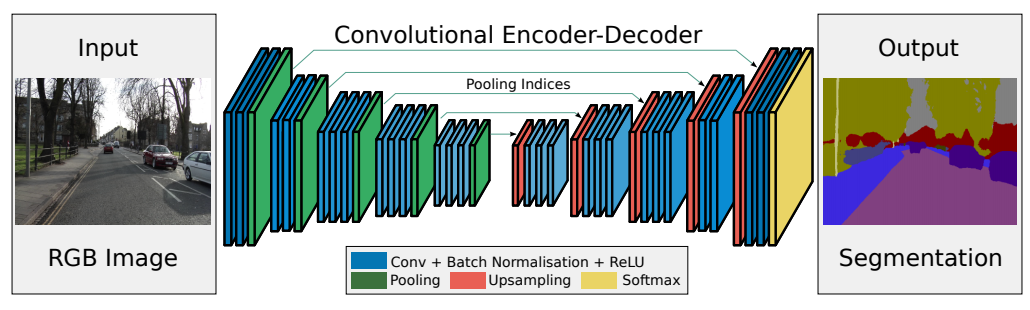

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки.

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Хорошие ресурсы по SegNet архитектуре:
1. https://medium.com/@nikdenof/segnet-from-scratch-using-pytorch-3fe9b4527239


In [27]:
class ConvReLU(nn.Module):
    def __init__(self, in_c, out_c, kernel_size=3, padding=1) -> None:
        super(ConvReLU, self).__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size=kernel_size, padding=padding)
        self.bn = nn.BatchNorm2d(out_c)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

In [28]:
class EncoderBlock(nn.Module):
    def __init__(self, in_c, out_c, depth=2, kernel_size=3, padding=1) -> None:
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(depth):
            self.layers.append(ConvReLU(in_c if i == 0 else out_c, out_c, kernel_size, padding))
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, ind = self.pool(x)
        return x, ind

In [29]:
class DecoderBlock(nn.Module):
    def __init__(self, in_c, out_c, depth=2, kernel_size=3, padding=1, classification=False) -> None:
        super(DecoderBlock, self).__init__()
        self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.layers = nn.ModuleList()
        for i in range(depth):
            if i == depth - 1 and classification:
                self.layers.append(nn.Conv2d(in_c, out_c, kernel_size=kernel_size, padding=padding))
            elif i == depth - 1:
                self.layers.append(ConvReLU(in_c, out_c, kernel_size=kernel_size, padding=padding))
            else:
                self.layers.append(ConvReLU(in_c, in_c, kernel_size=kernel_size, padding=padding))

    def forward(self, x, ind):
        x = self.unpool(x, ind)
        for layer in self.layers:
            x = layer(x)
        return x

In [30]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=64):
        super().__init__()
        # Encoder
        self.enc0 = EncoderBlock(in_channels, features)
        self.enc1 = EncoderBlock(features, features * 2)
        self.enc2 = EncoderBlock(features * 2, features * 4, depth=3)
        self.enc3 = EncoderBlock(features * 4, features * 8, depth=3)

        # Bottleneck
        self.bottleneck_enc = EncoderBlock(features * 8, features * 8, depth=3)
        self.bottleneck_dec = DecoderBlock(features * 8, features * 8, depth=3)

        # Decoder
        self.dec0 = DecoderBlock(features * 8, features * 4, depth=3)
        self.dec1 = DecoderBlock(features * 4, features * 2, depth=3)
        self.dec2 = DecoderBlock(features * 2, features)
        self.dec3 = DecoderBlock(features, out_channels, classification=True) #

    def forward(self, x):
        # encoder
        e0, ind0 = self.enc0(x)
        e1, ind1 = self.enc1(e0)
        e2, ind2 = self.enc2(e1)
        e3, ind3 = self.enc3(e2)

        # bottleneck
        b0, indb = self.bottleneck_enc(e3)
        b1 = self.bottleneck_dec(b0, indb)

        # decoder
        d0 = self.dec0(b1, ind3)
        d1 = self.dec1(d0, ind2)
        d2 = self.dec2(d1, ind1)

        # classification layer
        output = self.dec3(d2, ind0)
        return output

In [31]:
segnet_model = SegNet().to(device)

## Тренировка [1 балл]

Напишите функцию для обучения модели.

In [32]:
from tqdm.notebook import tqdm

In [33]:
def train(model, optimizer, criterion, epochs, train_loader, val_loader, device, model_name='segnet'):
    train_losses, val_losses = [], []
    best_iou = 0
    iou_metric = JaccardIndex(task='binary').to(device)

    for epoch in tqdm(range(epochs), desc="Epochs"):
        model.train()
        running_loss = 0
        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

            optimizer.zero_grad()
            Y_pred = model(X_batch)
            loss = criterion(Y_pred, Y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))

        # validation
        model.eval()
        val_loss, val_iou = 0, 0
        with torch.no_grad():
            for X_val, Y_val in val_loader:
                X_val, Y_val = X_val.to(device), Y_val.to(device)
                Y_pred_val = model(X_val)
                val_loss += criterion(Y_pred_val, Y_val).item()

                preds = (torch.sigmoid(Y_pred_val) > 0.5).float()
                val_iou += iou_metric(preds, Y_val)


        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train loss = {train_losses[-1]:.4f}, Val loss = {val_loss:.4f}, IoU = {val_iou:.4f}")

        # save best checkpoint
        if val_iou > best_iou:
            best_iou = val_iou
            if not os.path.isdir("checkpoint"):
                os.mkdir("checkpoint")
            torch.save({
                'net': model.state_dict(),
                'epoch': epoch,
                'iou': best_iou
            }, f'checkpoint/ckpt_{model_name}.pth')

    return train_losses, val_losses

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [34]:
train_loss, val_loss = train(segnet_model, optim.Adam(segnet_model.parameters(), lr=1e-4), bce_torch_with_logits, 15, train_dataloader, valid_dataloader, device)

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1: Train loss = 1154304.9375, Val loss = 1135392.2500, IoU = 0.2216
Epoch 2: Train loss = 1014138.4844, Val loss = 1127560.9375, IoU = 0.0010
Epoch 3: Train loss = 840686.6562, Val loss = 1105518.1250, IoU = 0.0000
Epoch 4: Train loss = 747662.3906, Val loss = 1074127.1875, IoU = 0.0000
Epoch 5: Train loss = 639545.7812, Val loss = 1039016.4062, IoU = 0.0000
Epoch 6: Train loss = 554939.2500, Val loss = 1018904.3125, IoU = 0.0000
Epoch 7: Train loss = 536350.5938, Val loss = 1019080.6250, IoU = 0.0000
Epoch 8: Train loss = 502912.6094, Val loss = 1040594.6562, IoU = 0.0040
Epoch 9: Train loss = 496838.9531, Val loss = 986106.5312, IoU = 0.1020
Epoch 10: Train loss = 428703.1719, Val loss = 902960.7188, IoU = 0.2399
Epoch 11: Train loss = 433888.6875, Val loss = 780049.2500, IoU = 0.3770
Epoch 12: Train loss = 367557.7266, Val loss = 568003.4688, IoU = 0.6051
Epoch 13: Train loss = 345544.6016, Val loss = 559566.2969, IoU = 0.5999
Epoch 14: Train loss = 358018.1797, Val loss = 436

## Инференс [1 балл]

После обучения модели напишите фукнцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [35]:
def test(model, criterion, dataloader, device, model_path=None):
    model.eval()

    if model_path:
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['net'])
        print(f"Loaded checkpoint from epoch {checkpoint['epoch']} with best IoU {checkpoint['iou']:.4f}")

    total_loss = 0
    total_iou = 0
    iou_metric = JaccardIndex(task='binary').to(device)

    with torch.no_grad():
        for X_batch, Y_batch in dataloader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            Y_pred = model(X_batch)

            loss = criterion(Y_pred, Y_batch)
            total_loss += loss.item()

            preds = (torch.sigmoid(Y_pred) > 0.5).float()
            total_iou += iou_metric(preds, Y_batch)

    avg_loss = total_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    print(f"Test loss: {avg_loss:.4f}, Test IoU: {avg_iou:.4f}")

    return avg_loss, avg_iou


In [36]:
test(segnet_model, bce_torch_with_logits, train_dataloader, device, "checkpoint/ckpt_segnet.pth")

Loaded checkpoint from epoch 14 with best IoU 0.7783
Test loss: 336454.0781, Test IoU: 0.8195


(336454.078125, tensor(0.8195, device='cuda:0'))

# Мир других лоссов!

## Дополнительные функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [37]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    labels = labels.float()

    intersection = (preds * labels).sum(dim=(1, 2, 3))
    total = preds.sum(dim=(1, 2, 3)) + labels.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (total + eps)

    return dice.mean()


Проверим на корректность функцию dice_score:

In [38]:
from torchmetrics.segmentation import DiceScore

logits = dummpy_sample['logits']
labels = dummpy_sample['labels']

# делаем бинарные маски явно
sig = torch.sigmoid(logits)
binarized_preds = (sig > 0.5).int()
binarized_labels = labels.int()

# считаем метрику
metric_dice = DiceScore(num_classes=1)
score1 = metric_dice(binarized_preds, binarized_labels)

# ручная реализацию
score2 = dice_score(logits, labels)

assert torch.allclose(score1, score2, atol=1e-4)


Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [39]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor, eps=1e-8):

    probs = torch.sigmoid(logits)
    labels = labels.float()

    intersection = (probs * labels).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + labels.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)
    loss = 1 - dice
    return loss.mean()

In [40]:
!pip install -U segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


In [41]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [44]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [46]:
def focal_loss(y_real, y_pred, gamma=2):
    y_real = y_real.float()
    bce = F.binary_cross_entropy_with_logits(y_pred, y_real, reduction='none')
    probs = torch.sigmoid(y_pred)
    pt = probs * y_real + (1 - probs) * (1 - y_real)
    loss = (1 - pt) ** gamma * bce
    return loss.sum()


Проверка корректности функции:

In [47]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [48]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)


## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

Имлементируем Tversky loss

https://docs.monai.io/en/stable/losses.html#tverskyloss

In [49]:
def tversky_loss(y_pred, y_true, alpha=0.5, beta=0.5, eps=1e-8):
    y_true = y_true.float()
    probs = torch.sigmoid(y_pred)

    TP = (probs * y_true).sum(dim=(1, 2, 3))
    FP = (probs * (1 - y_true)).sum(dim=(1, 2, 3))
    FN = ((1 - probs) * y_true).sum(dim=(1, 2, 3))

    tversky = (TP + eps) / (TP + alpha * FP + beta * FN + eps)
    return 1 - tversky.mean()


In [50]:
from segmentation_models_pytorch.losses import TverskyLoss
tversky_loss_torch = TverskyLoss(mode='binary', log_loss=False, alpha=0.5, beta=0.5)


In [51]:
logits = dummpy_sample['logits']
labels = dummpy_sample['labels']

loss_lib = tversky_loss_torch(logits, labels)
loss_custom = tversky_loss(logits, labels, alpha=0.5, beta=0.5)

print("Torch Tversky Loss:", loss_lib.item())
print("Custom Tversky Loss:", loss_custom.item())

assert torch.allclose(loss_lib, loss_custom, atol=1e-4)

Torch Tversky Loss: 0.5755997896194458
Custom Tversky Loss: 0.5755997896194458


## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [52]:
def dice_criterion(pred, target):
    return dice_loss(pred, target)

def focal_criterion(pred, target):
    return focal_loss(target, pred)


In [64]:
loss_fns = {
    'BCE': nn.BCEWithLogitsLoss(),
    'Dice': dice_criterion,
    'Focal': focal_criterion
}

results = {}

for name, loss_fn in loss_fns.items():
    print(f'\n--- Training with {name} loss ---\n')

    model = SegNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_loss, val_loss = train(
        model,
        optimizer,
        loss_fn,
        epochs=20,
        train_loader=train_dataloader,
        val_loader=valid_dataloader,
        device=device
    )

    results[name] = {
        'model': model,
        'train_loss': train_loss,
        'val_loss': val_loss
    }



--- Training with BCE loss ---



Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Train loss = 0.6774, Val loss = 0.6923, IoU = 0.1856
Epoch 2: Train loss = 0.6392, Val loss = 0.6856, IoU = 0.0074
Epoch 3: Train loss = 0.5613, Val loss = 0.6707, IoU = 0.0001
Epoch 4: Train loss = 0.4931, Val loss = 0.6442, IoU = 0.0000
Epoch 5: Train loss = 0.4387, Val loss = 0.6250, IoU = 0.0000
Epoch 6: Train loss = 0.3700, Val loss = 0.6331, IoU = 0.0000
Epoch 7: Train loss = 0.3497, Val loss = 0.6726, IoU = 0.0009
Epoch 8: Train loss = 0.3025, Val loss = 0.6647, IoU = 0.0952
Epoch 9: Train loss = 0.3014, Val loss = 0.4340, IoU = 0.4809
Epoch 10: Train loss = 0.2543, Val loss = 0.4479, IoU = 0.4752
Epoch 11: Train loss = 0.2321, Val loss = 0.3210, IoU = 0.6688
Epoch 12: Train loss = 0.2162, Val loss = 0.3419, IoU = 0.6141
Epoch 13: Train loss = 0.2148, Val loss = 0.2797, IoU = 0.7014
Epoch 14: Train loss = 0.2075, Val loss = 0.2895, IoU = 0.7029
Epoch 15: Train loss = 0.2028, Val loss = 0.2461, IoU = 0.7547
Epoch 16: Train loss = 0.1729, Val loss = 0.2341, IoU = 0.7550
E

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Train loss = 0.5834, Val loss = 0.6587, IoU = 0.0000
Epoch 2: Train loss = 0.5087, Val loss = 0.6595, IoU = 0.0000
Epoch 3: Train loss = 0.4742, Val loss = 0.6618, IoU = 0.0000
Epoch 4: Train loss = 0.4488, Val loss = 0.6663, IoU = 0.0000
Epoch 5: Train loss = 0.4287, Val loss = 0.6736, IoU = 0.0000
Epoch 6: Train loss = 0.4079, Val loss = 0.6834, IoU = 0.0000
Epoch 7: Train loss = 0.3985, Val loss = 0.6962, IoU = 0.0015
Epoch 8: Train loss = 0.3847, Val loss = 0.7020, IoU = 0.0185
Epoch 9: Train loss = 0.3667, Val loss = 0.5500, IoU = 0.3753
Epoch 10: Train loss = 0.3659, Val loss = 0.4914, IoU = 0.5073
Epoch 11: Train loss = 0.3439, Val loss = 0.4368, IoU = 0.6154
Epoch 12: Train loss = 0.3379, Val loss = 0.3362, IoU = 0.7873
Epoch 13: Train loss = 0.3240, Val loss = 0.3224, IoU = 0.8070
Epoch 14: Train loss = 0.3116, Val loss = 0.3103, IoU = 0.8207
Epoch 15: Train loss = 0.2932, Val loss = 0.3007, IoU = 0.8236
Epoch 16: Train loss = 0.2849, Val loss = 0.2861, IoU = 0.8191
E

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Train loss = 299369.8203, Val loss = 277635.4531, IoU = 0.0000
Epoch 2: Train loss = 260208.8008, Val loss = 276027.0938, IoU = 0.0000
Epoch 3: Train loss = 188759.1055, Val loss = 268824.4062, IoU = 0.0000
Epoch 4: Train loss = 141930.3984, Val loss = 259038.5469, IoU = 0.0000
Epoch 5: Train loss = 122021.0449, Val loss = 263337.4219, IoU = 0.0000
Epoch 6: Train loss = 99044.2637, Val loss = 301471.9062, IoU = 0.0000
Epoch 7: Train loss = 94606.4727, Val loss = 384910.2500, IoU = 0.0000
Epoch 8: Train loss = 80021.9531, Val loss = 465001.0312, IoU = 0.0000
Epoch 9: Train loss = 77557.7949, Val loss = 526351.1406, IoU = 0.0040
Epoch 10: Train loss = 62585.7949, Val loss = 394003.9844, IoU = 0.2088
Epoch 11: Train loss = 57870.6895, Val loss = 294526.7422, IoU = 0.4351
Epoch 12: Train loss = 61400.4121, Val loss = 172087.1328, IoU = 0.6198
Epoch 13: Train loss = 75546.6094, Val loss = 138483.5469, IoU = 0.6475
Epoch 14: Train loss = 63675.7188, Val loss = 113762.1719, IoU = 0.6

 При каком лоссе модель сходится быстрее?


Все лоссы долго разгоняются, первые 6-8 эпох IoU около 0, далее быстрее всех идет BCE Loss, на 9 эпохе 0.48, на 12 - 0.61.
Далее Dice его обгоняет - на 9 эпохе 0.37, а на 12 - 0.7

У Focal loss - еще медленнее - на 9 - 0.004, на 12 - 0.61. Однако потом разгоняется и результат получается хороший

Получается focal loss < BCE Loss и Dice loss
а BCE Loss ~ Dice loss

При каком лоссе модель выдает наилучшую метрику?
Все выдают очень близкие числа наибольший

- Focal Loss - 0.8388

# Новая модель!

## U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

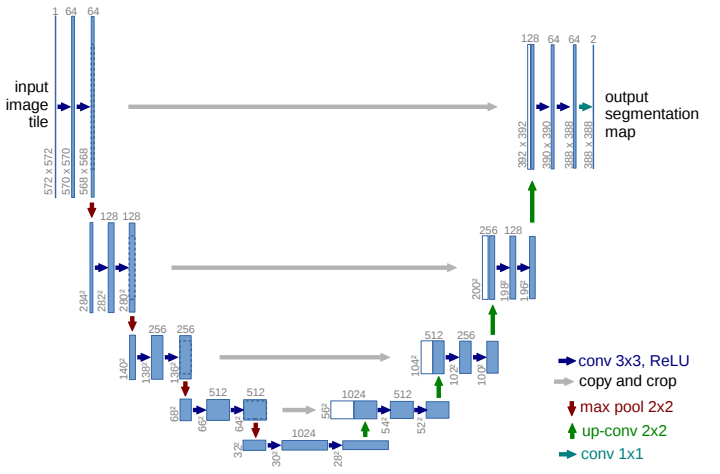

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

In [55]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, n_class, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))
        d4 = self.down4(self.pool3(d3))
        b = self.bottleneck(self.pool4(d4))

        u4 = self.up4(b)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.dec4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.dec3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.dec2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.dec1(u1)

        return self.out_conv(u1)


In [58]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



In [57]:
loss_fns = {
    'BCE': nn.BCEWithLogitsLoss(),
    'Dice': dice_criterion,
    'Focal': focal_criterion
}

unet_results = {}

for name, criterion in loss_fns.items():
    print(f"\n--- Training UNet with {name} Loss ---\n")

    model = UNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=5e-4) #c 1e-4 IoU - 0 почти всегда

    train_loss, val_loss = train(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        epochs=20,
        train_loader=train_dataloader,
        val_loader=valid_dataloader,
        device=device,
        model_name=f"unet_{name.lower()}"
    )

    unet_results[name] = {
        'model': model,
        'train_loss': train_loss,
        'val_loss': val_loss
    }



--- Training UNet with BCE Loss ---



Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Train loss = 0.6981, Val loss = 0.6628, IoU = 0.0011
Epoch 2: Train loss = 0.8144, Val loss = 0.5831, IoU = 0.0000
Epoch 3: Train loss = 0.6016, Val loss = 0.6108, IoU = 0.0000
Epoch 4: Train loss = 0.6117, Val loss = 0.5947, IoU = 0.0000
Epoch 5: Train loss = 0.5905, Val loss = 0.5650, IoU = 0.0000
Epoch 6: Train loss = 0.5697, Val loss = 0.5505, IoU = 0.0000
Epoch 7: Train loss = 0.5574, Val loss = 0.5362, IoU = 0.0000
Epoch 8: Train loss = 0.5408, Val loss = 0.5173, IoU = 0.0005
Epoch 9: Train loss = 0.5209, Val loss = 0.4907, IoU = 0.0346
Epoch 10: Train loss = 0.4963, Val loss = 0.4607, IoU = 0.1991
Epoch 11: Train loss = 0.4736, Val loss = 0.4347, IoU = 0.3919
Epoch 12: Train loss = 0.4634, Val loss = 0.4295, IoU = 0.4286
Epoch 13: Train loss = 0.4547, Val loss = 0.4098, IoU = 0.5655
Epoch 14: Train loss = 0.4427, Val loss = 0.3996, IoU = 0.5816
Epoch 15: Train loss = 0.4232, Val loss = 0.3617, IoU = 0.5943
Epoch 16: Train loss = 0.6707, Val loss = 0.5217, IoU = 0.2540
E

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Train loss = 0.6545, Val loss = 0.6472, IoU = 0.3100
Epoch 2: Train loss = 0.6128, Val loss = 0.5646, IoU = 0.3099
Epoch 3: Train loss = 0.5552, Val loss = 0.5648, IoU = 0.3099
Epoch 4: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 5: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 6: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 7: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 8: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 9: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 10: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 11: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 12: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 13: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 14: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 15: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
Epoch 16: Train loss = 0.5553, Val loss = 0.5648, IoU = 0.3099
E

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Train loss = 291529.4844, Val loss = 349571.8438, IoU = 0.0001
Epoch 2: Train loss = 290446.7617, Val loss = 259453.8750, IoU = 0.0015
Epoch 3: Train loss = 253562.9922, Val loss = 233662.2656, IoU = 0.0000
Epoch 4: Train loss = 233411.5703, Val loss = 228701.1484, IoU = 0.0000
Epoch 5: Train loss = 231215.0352, Val loss = 218379.8672, IoU = 0.0001
Epoch 6: Train loss = 219038.4688, Val loss = 206938.5781, IoU = 0.0063
Epoch 7: Train loss = 207931.3594, Val loss = 189958.7578, IoU = 0.3429
Epoch 8: Train loss = 197303.4922, Val loss = 194208.2422, IoU = 0.3174
Epoch 9: Train loss = 201948.7461, Val loss = 181370.9844, IoU = 0.5635
Epoch 10: Train loss = 198688.4141, Val loss = 177530.7031, IoU = 0.5768
Epoch 11: Train loss = 188782.3125, Val loss = 176104.9766, IoU = 0.5005
Epoch 12: Train loss = 188041.4336, Val loss = 170455.4844, IoU = 0.5880
Epoch 13: Train loss = 184704.4570, Val loss = 168438.0469, IoU = 0.5937
Epoch 14: Train loss = 187996.9219, Val loss = 162821.1250, 

- Какая модель даёт лучшие значения по метрике?


SegNet лучше - 0.83 (Focal) против U-Net - 0.65 (Focal Loss)

- Какая модель даёт лучшие значения по лоссам(val)?

  -   Segnet лучше
    - BCE - 0.1898
    - Dice - 0.2592
    - Focal - 58808
  - U-NET
    - BCE - 0.3617
    - Dice - 0.5648
    - Focal - 160358


- Какая модель обучается быстрее?

SegNet + Dice Roll достиг 0.78 уже к эпохе 12
U-Net при текущей имплементации не дошел до 0.7, наиболее близок был с Focal Loss до 0.65, куда он дошел к 17 эпохе,

SegNet лучше.

В
 целом при текущей имплементации U-Net хуже, нужно дорабатывать, менять параметры и тд.






In [79]:
def visualize(model, images, labels, title=''):
    model.eval()
    plt.figure(figsize=(12, 9))
    with torch.no_grad():
        preds = torch.sigmoid(model(images)) > 0.5

    for i in range(3):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        true_mask = labels[i][0].cpu().numpy()
        pred_mask = preds[i][0].cpu().numpy()

        plt.subplot(3, 3, i * 3 + 1)
        plt.imshow(img)
        plt.title('Image')
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 2)
        plt.imshow(true_mask, cmap='gray')
        plt.title('Ground Truth')
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title('Prediction')
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


In [80]:
images, labels = next(iter(valid_dataloader))
images, labels = images.to(device), labels.to(device)


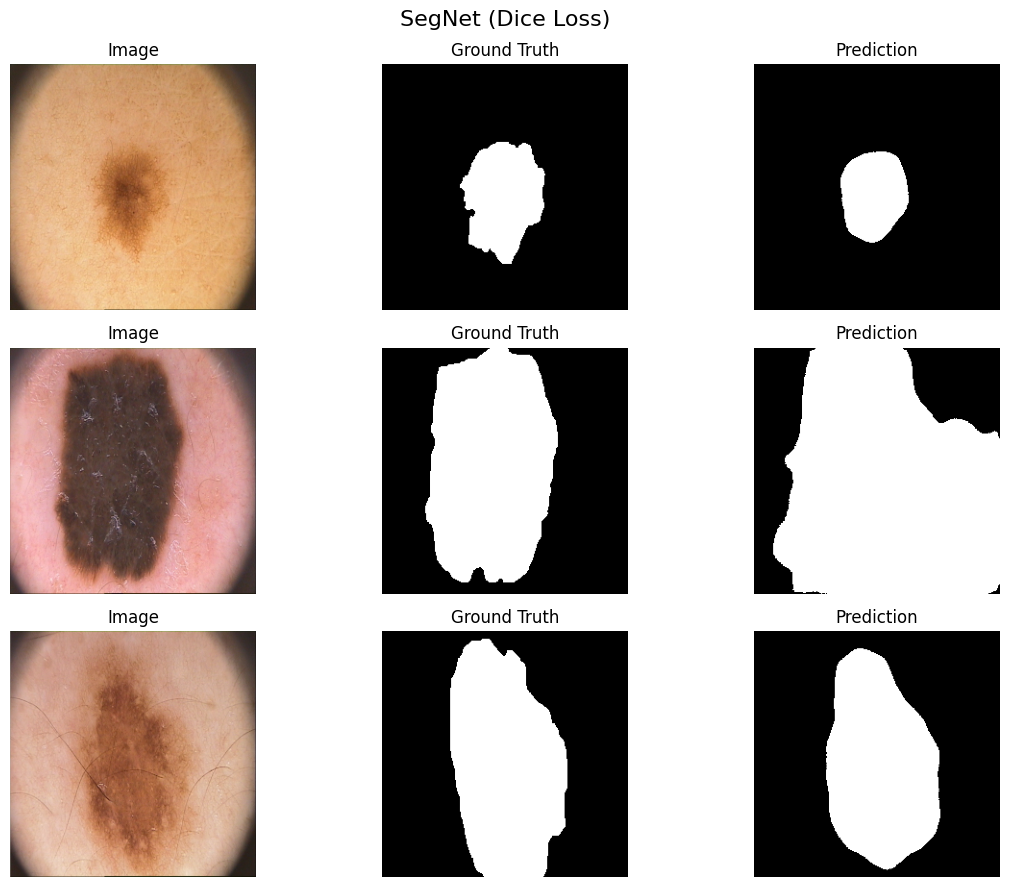

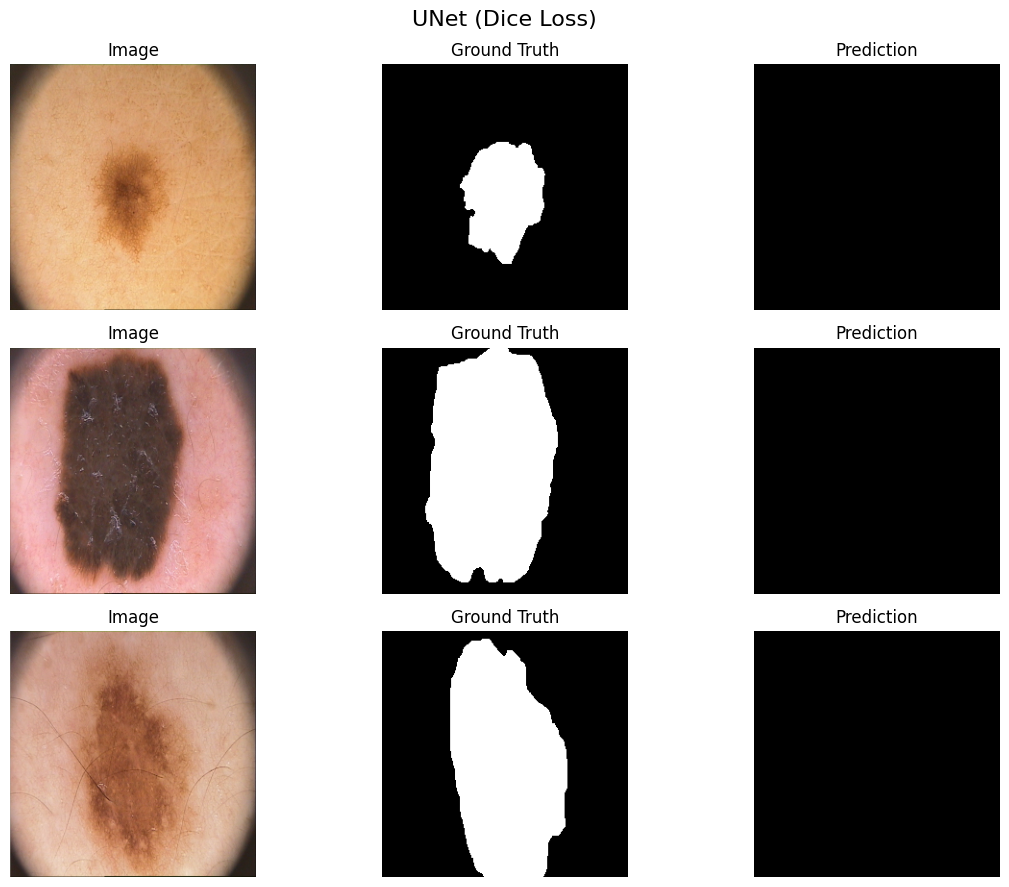

In [81]:
visualize(results['Dice']['model'], images, labels, title='SegNet (Dice Loss)')

visualize(unet_results['Dice']['model'], images, labels, title='UNet (Dice Loss)')



UNet у нас просто не работает с Dice Loss(

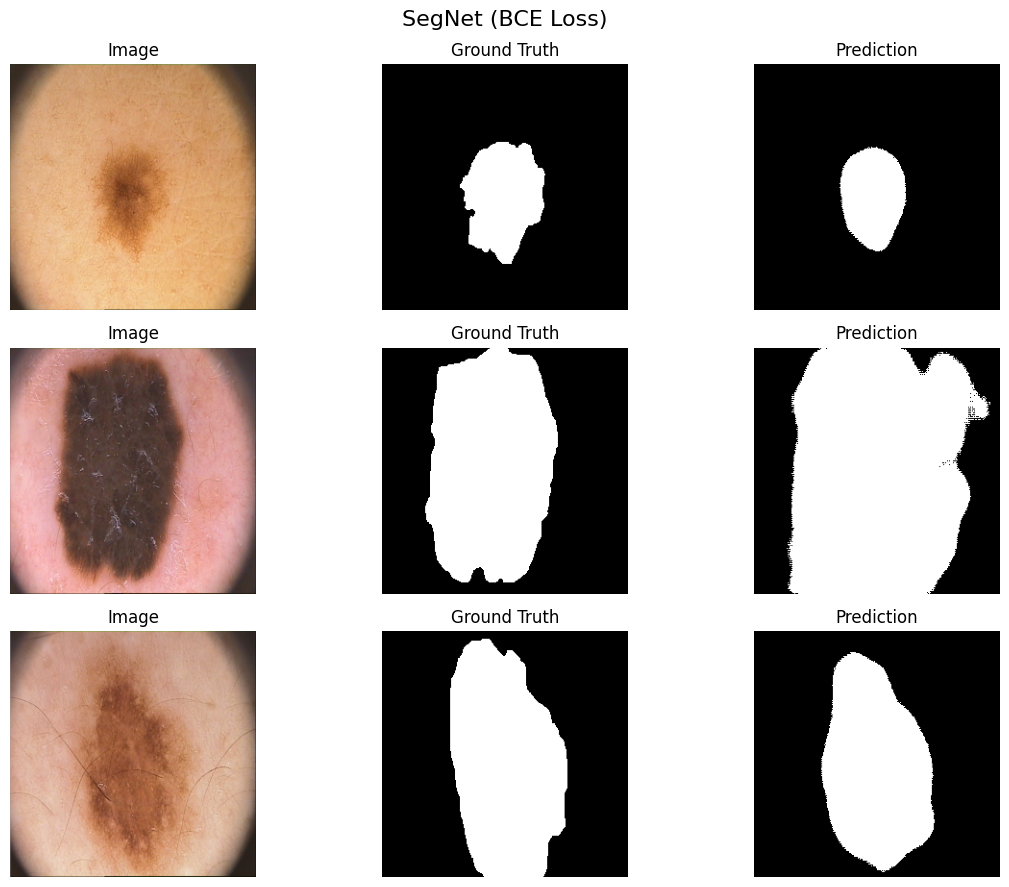

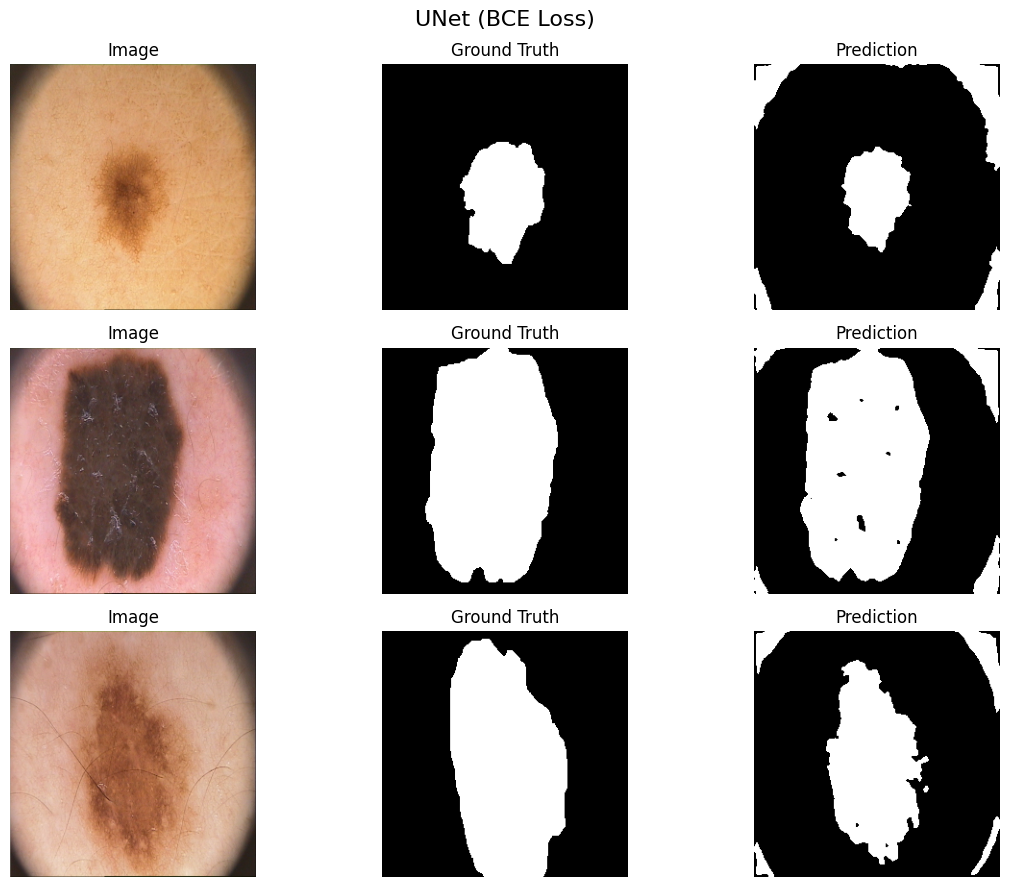

In [82]:
visualize(results['BCE']['model'], images, labels, title='SegNet (BCE Loss)')

visualize(unet_results['BCE']['model'], images, labels, title='UNet (BCE Loss)')



Еще раз вывод - хоть U-Net и мощнее, либо у нас мало картинок, либо её надо докручивать чтобы работала лучше, для нас SegNet работает хорошо!